# The point of this noteboook is to see how BG Noise looks on the motor output scale

100%|██████████| 1/1 [00:00<00:00, 10.92it/s]


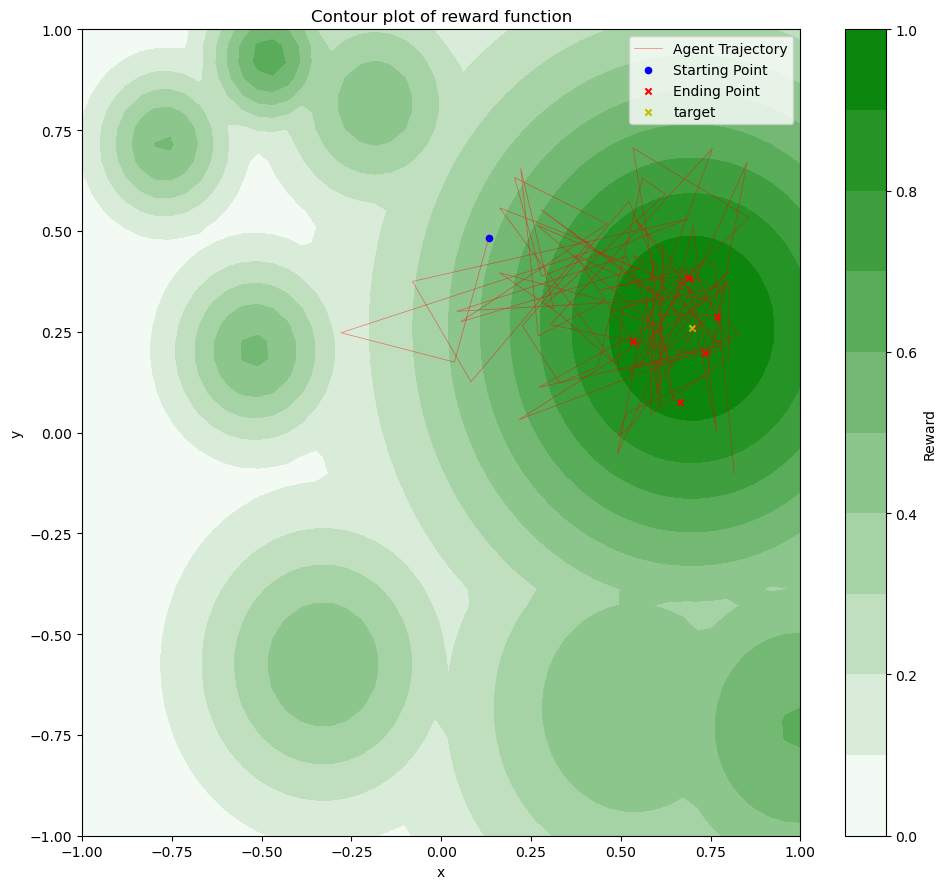

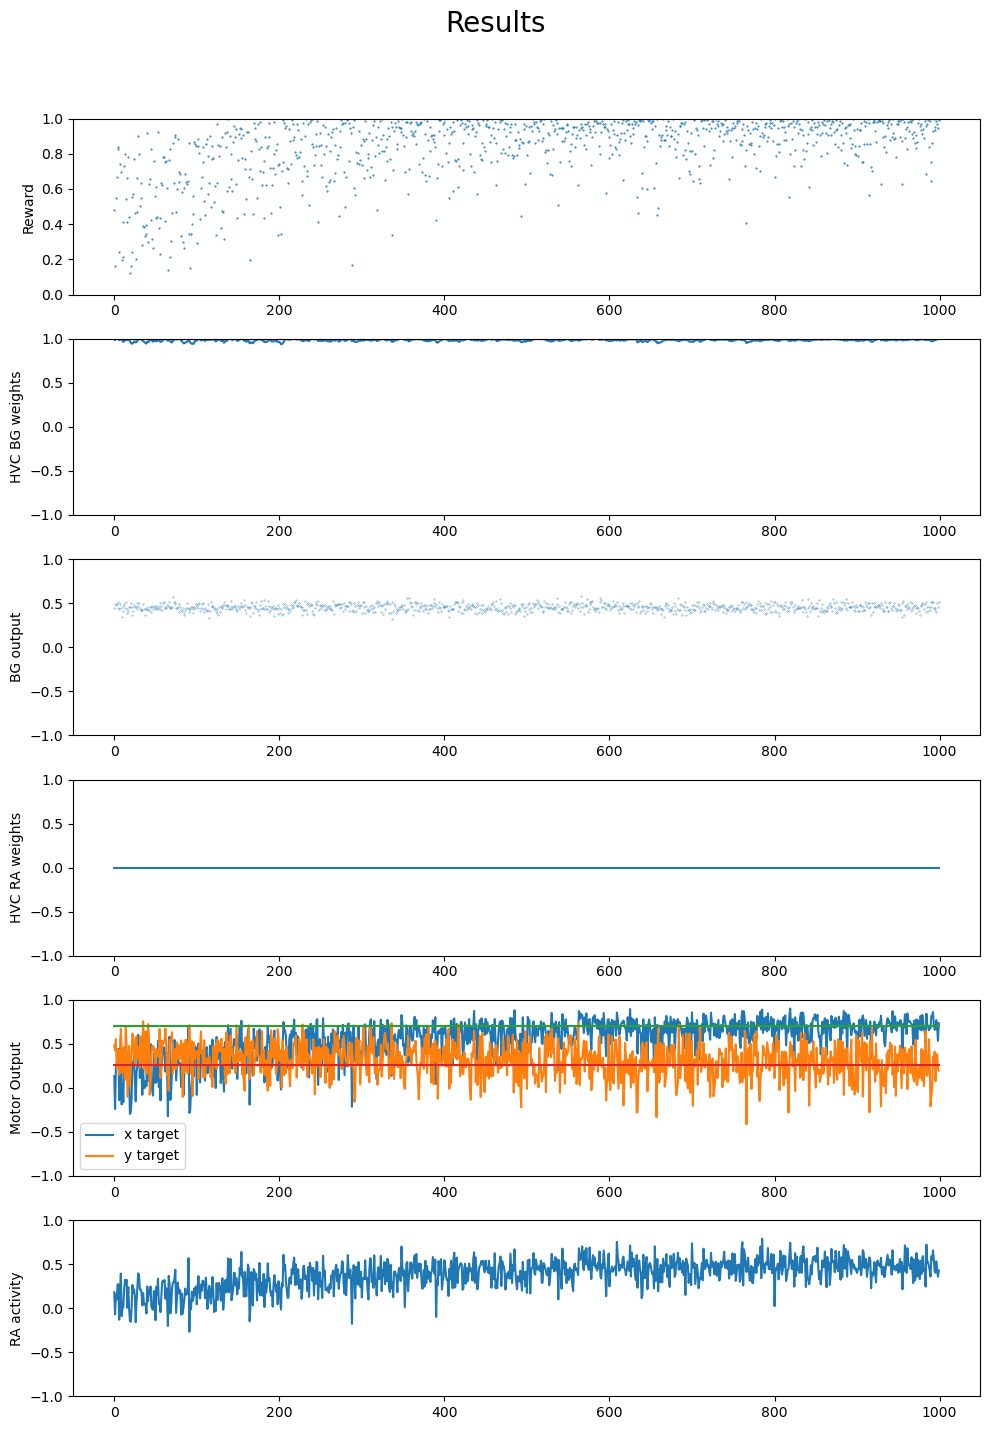

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap

# 2D reward landscapesno
def gaussian(coordinates, height, mean, spread):
    ''' Returns a scalar value for given coordinates in a 2D gaussian distribution'''
    x, y = coordinates[0], coordinates[1]
    return height * np.exp(-((x-mean[0])**2 + (y-mean[1])**2)/(2*spread**2))

def new_sigmoid(x, m=0, a=0):
    """ Returns an output between -1 and 1 """
    return (2 / (1 + np.exp(-1*(x-a)*m))) - 1

def sigmoid(x, m =0.0 , a=0.0 ):
    """ Returns an output between 0 and 1 """
    return 1 / (1 + np.exp(-1*(x-a)*m))


''' Needs tuning to escape local max '''
RANDOM_SEED = 410 #np.random.randint(0, 1000)
np.random.seed(RANDOM_SEED)
CENTER = np.random.uniform(-0.9, 0.9, 2)
# layer sizes
HVC_SIZE = 100
BG_SIZE = 50
RA_SIZE = 100 
MC_SIZE = 2
N_RA_CLUSTERS = 2
N_BG_CLUSTERS = 2

# sigmoid layer parameters
BG_sig_slope = 1  # 1 lesser, slower the learning # BG sigmoidal should be as less steep as possible
BG_sig_mid = 0
RA_sig_slope = 30 # 30 RA sigmoidal should be as steep as possible
RA_sig_mid = 0
MC_sig_slope = 5 # 5 if lesser -> more difficult to climb the hill, assymptotes before 
MC_sig_mid = 0

# parameters
reward_window = 10
input = np.zeros(HVC_SIZE)
input[1] = 1
BG_noise = 0.1

# Run paraneters

N_DISTRACTORS = 10
LEARING_RATE_RL = 0.1
LEARNING_RATE_HL = 1.1e-5
TRIALS = 1000
DAYS = 1

# modes
ANNEALING = False
HEBBIAN_LEARNING = False
balance_factor = 1

# Model
class NN:
    def __init__(self, hvc_size, bg_size, ra_size, mc_size):
        self.W_hvc_bg = np.random.uniform(-1, 1, (hvc_size, bg_size)) # changing from -1 to 1 
        self.W_hvc_ra = np.zeros((hvc_size, ra_size)) # connections start from 0 and then increase
        self.W_bg_ra = np.random.uniform(0, 1, (bg_size, ra_size)) # const from 0 to 1
        self.W_ra_mc = np.random.uniform(0, 1, (ra_size, mc_size)) # const from 0 to 1
        # channel from ra to mc
        for i in range(N_RA_CLUSTERS):
            segPath = np.diag(np.ones(N_RA_CLUSTERS, int))[i]
            self.W_ra_mc[i*ra_size//N_RA_CLUSTERS : (i+1)*ra_size//N_RA_CLUSTERS] *= segPath
        # channel from bg to ra such that motor cortex components are independent of each other
        for i in range(N_BG_CLUSTERS):
            segPath = np.diag(np.ones(N_BG_CLUSTERS, int))[i]
            self.W_bg_ra[i*bg_size//N_BG_CLUSTERS : (i+1)*bg_size//N_BG_CLUSTERS] *= [j for j in segPath for r in range(RA_SIZE//N_RA_CLUSTERS)]

        self.hvc_size = hvc_size
        self.bg_size = bg_size
        self.ra_size = ra_size
        self.mc_size = mc_size  
        self.ra_cluster_size = ra_size // N_RA_CLUSTERS
        self.bg_cluster_size = bg_size // N_BG_CLUSTERS
            
    def forward(self, hvc_array):
        self.hvc = hvc_array
        # count number of 1 in hvc, divide bg by that number
        num_ones = np.count_nonzero(hvc_array == 1)
        self.bg = new_sigmoid(np.dot(hvc_array/num_ones, self.W_hvc_bg) + np.random.normal(0, BG_noise, self.bg_size), m = BG_sig_slope, a = BG_sig_mid)
        self.ra = new_sigmoid(np.dot(self.bg, self.W_bg_ra/np.sum(self.W_bg_ra, axis=0)) + np.dot(hvc_array/num_ones, self.W_hvc_ra) * balance_factor * HEBBIAN_LEARNING, m = RA_sig_slope, a = RA_sig_mid) 
        ''' even after BG cut off, output should remain still the same'''
        self.mc = new_sigmoid(np.dot(self.ra, self.W_ra_mc/np.sum(self.W_ra_mc, axis=0)), m = MC_sig_slope, a = MC_sig_mid)
        # self.bg = np.dot(hvc_array/num_ones, self.W_hvc_bg)  #outputs to +-0.98
        # self.ra = np.dot(self.bg, self.W_bg_ra/np.sum(self.W_bg_ra, axis=0)) + np.dot(hvc_array/num_ones, self.W_hvc_ra) * balance_factor * HEBBIAN_LEARNING #outputs to +-0.40
        # self.mc = np.dot(self.ra, self.W_ra_mc/np.sum(self.W_ra_mc, axis=0)) # outputs to +-0.50
        return self.mc, self.ra, self.bg

class Environment:
    def __init__(self, hvc_size, bg_size, ra_size, mc_size):
        self.hvc_size = hvc_size
        self.bg_size = bg_size
        self.ra_size = ra_size
        self.mc_size = mc_size
        self.model = NN(hvc_size, bg_size, ra_size, mc_size)
        self.heights = np.random.uniform(0.2, 0.7, N_DISTRACTORS)
        self.means = np.random.uniform(-1, 1, (N_DISTRACTORS, 2))
        self.spreads = np.random.uniform(0.1, 0.4, N_DISTRACTORS)
        self.rewards = []
        self.actions = []
        self.hvc_bg_array = []
        self.bg_out = []
        self.hvc_ra_array = []
        self.ra_out = []
        self.dw_day_array = []
        self.pot_array = []
        
    def get_reward(self, coordinates):
        reward_scape = gaussian(coordinates, 1, CENTER, 0.5)
        if N_DISTRACTORS == 0:
            return reward_scape
        hills = []
        hills.append(reward_scape)
        for i in range(N_DISTRACTORS):
            height = self.heights[i]
            mean = self.means[i]
            spread = self.spreads[i]
            hills.append(gaussian(coordinates, height, mean, spread))
        return np.maximum.reduce(hills)
    
    def run(self, iterations, learning_rate, learning_rate_hl, input_hvc, annealing = False):
        for day in tqdm(range(DAYS)):
            dw_day = 0
            for iter in range(iterations):
                # reward and baseline
                action, ra, bg = self.model.forward(input_hvc)

                reward = self.get_reward(action)
                self.rewards.append(reward)
                self.actions.append(action)
                if iter < 1:
                    reward_baseline = 0
                else:
                    reward_baseline = np.mean(self.rewards[-reward_window:-1])
                # Updates 
                # RL update
                dw_hvc_bg = learning_rate*(reward - reward_baseline)*input_hvc.reshape(self.hvc_size,1)*self.model.bg # RL update
                self.model.W_hvc_bg += dw_hvc_bg
                # HL update
                dw_hvc_ra = learning_rate_hl*input_hvc.reshape(self.hvc_size,1)*self.model.ra*HEBBIAN_LEARNING # lr is supposed to be much smaller here
                self.model.W_hvc_ra += dw_hvc_ra
                # bound weights between +-1
                self.model.W_hvc_bg = np.clip(self.model.W_hvc_bg, -1, 1)
                self.model.W_hvc_ra = np.clip(self.model.W_hvc_ra, -1, 1)
                dw_day += np.mean(np.abs(dw_hvc_bg))
                
                self.hvc_bg_array.append(self.model.W_hvc_bg[1,1])
                self.bg_out.append(bg[1])
                self.hvc_ra_array.append(self.model.W_hvc_ra[1,1])
                self.ra_out.append(ra[1])
            # if day % 6 == 0:   
                #     tqdm.write(f'Iteration: {iter}, Action: {action}, Reward: {reward}, Reward Baseline: {reward_baseline}') 
                # tqdm.write(f'Day: {day}, Action: {action}, Reward: {reward}, Reward Baseline: {reward_baseline}')    
            # Annealing
            if annealing:
                ''' input daily sum, output scaling factor for potentiation'''
                p = dw_day*100
                self.dw_day_array.append(p)
                p = 1* sigmoid(p, m = 2.5, a = 3)
                potentiation_factor = np.zeros((self.hvc_size))
                self.pot_array.append(1-p)
                potentiation_factor[1] = 1-p 
                night_noise = np.random.uniform(-1, 1, self.bg_size) # make it lognormal
                dw_night = LEARING_RATE_RL*potentiation_factor.reshape(self.hvc_size,1)*night_noise*20
                self.model.W_hvc_bg += dw_night
                self.model.W_hvc_bg = (self.model.W_hvc_bg+1) % 2 -1 
                # self.model.W_hvc_bg = np.clip(self.model.W_hvc_bg, -1, 1)
            
                
    def plot_trajectory(self):
        fig, axs = plt.subplots(figsize=(10, 9))
        # generate grid 
        x, y = np.linspace(-1, 1, 50), np.linspace(-1, 1, 50)
        X, Y = np.meshgrid(x, y)
        Z = self.get_reward([X, Y])
        
        # Plot contour
        cmap = LinearSegmentedColormap.from_list('white_to_green', ['white', 'green'])
        contour = axs.contourf(X, Y, Z, levels=10, cmap=cmap)
        fig.colorbar(contour, ax=axs, label='Reward')
        
        # plot trajectory
        x_traj, y_traj = zip(*self.actions)
        axs.plot(x_traj[::10], y_traj[::10], 'r', label='Agent Trajectory', alpha = 0.5, linewidth = 0.5) # Plot every 20th point for efficiency
        axs.scatter(x_traj[0], y_traj[0], s=20, c='b', label='Starting Point')  # Plot first point as red circle
        axs.scatter(x_traj[-5:], y_traj[-5:], s=20, c='r', marker='x', label='Ending Point') # type: ignore
        axs.scatter(CENTER[0], CENTER[1], s=20, c='y', marker='x', label='target')  # type: ignore
        # labels
        axs.set_title('Contour plot of reward function')
        axs.set_xlabel('x')
        axs.set_ylabel('y')
        axs.legend()
        plt.tight_layout()
        plt.show()
        
    def plot_results(self):
        fig, axs = plt.subplots(6, 1, figsize=(10, 15))
        axs[0].plot(self.rewards, '.', markersize=1, linestyle='None')
        axs[0].set_ylim(0, 1)
        axs[0].set_ylabel('Reward')
        axs[1].plot(self.hvc_bg_array)
        axs[1].set_ylim(-1, 1)
        axs[1].set_ylabel('HVC BG weights')
        axs[2].plot(self.bg_out,'.', markersize=0.5, linestyle='None')
        axs[2].set_ylim(-1, 1)
        axs[2].set_ylabel('BG output')
        axs[3].plot(self.hvc_ra_array)
        axs[3].set_ylim(-1, 1)
        axs[3].set_ylabel('HVC RA weights')
        axs[4].plot(self.actions)
        axs[4].plot(CENTER[0]*np.ones(TRIALS*DAYS))
        axs[4].plot(CENTER[1]*np.ones(TRIALS*DAYS))
        axs[4].legend(['x target', 'y target'])
        axs[4].set_ylabel('Motor Output')
        axs[4].set_ylim(-1, 1)
        axs[5].plot(self.ra_out)
        axs[5].set_ylim(-1, 1)
        axs[5].set_ylabel('RA activity')
        fig.suptitle('Results', fontsize=20)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    
    def plot_dw_day(self):
        # Expand dw_day_array and pot_array to match the size of rewards
        expanded_dw_day_array = np.repeat(self.dw_day_array, len(self.rewards) // len(self.dw_day_array))
        expanded_pot_array = np.repeat(self.pot_array, len(self.rewards) // len(self.pot_array))
        plt.title('Annealing')
        plt.plot(expanded_dw_day_array, markersize=1, label='dW_day')
        plt.plot(expanded_pot_array, markersize=1, label='Potentiation factor')
        plt.plot(self.rewards, '.', markersize=1, label='Reward')
        plt.xlabel('Days')
        plt.ylabel('dW_day')
        plt.legend()
        plt.show()
        
env = Environment(HVC_SIZE, BG_SIZE, RA_SIZE, MC_SIZE)
env.run(TRIALS, LEARING_RATE_RL, LEARNING_RATE_HL, input, ANNEALING)
env.plot_trajectory()
env.plot_results()
# env.plot_dw_day()
